# Formularios: uso, lentitud e impacto

Este cuaderno separa tres perspectivas: formularios mas lentos, mas usados y con mayor impacto total en tiempo consumido.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd()
candidate_roots = [
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent if NOTEBOOK_CWD.name == 'notebooks' else NOTEBOOK_CWD,
    NOTEBOOK_CWD / 'observability' / 'd365-fo-observability',
]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'kql_runner.py').exists() and (candidate / 'queries').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('No se pudo localizar observability/d365-fo-observability desde el directorio actual')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from kql_runner import build_client, load_config, load_kql, plot_bar, run_kql, set_analyst_theme, summarize_top_items

config = load_config()
client = build_client(config=config)
FORMS_DAYS = config['query_days']
TOP_N = 15
set_analyst_theme()

Ejecutando: Slow forms
Filas devueltas: 30


,FormName,Executions,AvgDurationSeconds,P95DurationSeconds,MaxDurationSeconds
0,LedgerTransVoucher1,115,0.51,4.41,6.80
1,BankAutomationReconciliationWorksheet,146,2.26,3.73,4.98
2,CustCollectionsPoolsListPage,11,2.03,3.73,3.73
3,BankAccountTableListPage,14,0.80,2.81,2.81
4,CustTableListPage,119,1.44,2.38,3.95
5,ReconciliationAutomationWorkspaceOverviewPage,10,1.15,2.02,2.02
6,VendTableListPage,100,1.28,1.80,19.23
7,BankTreasurerWorkspace,17,0.41,1.80,1.80
8,DefaultDashboard,175,0.79,1.53,10.96
9,LedgerTransBase,17,0.36,1.48,1.48


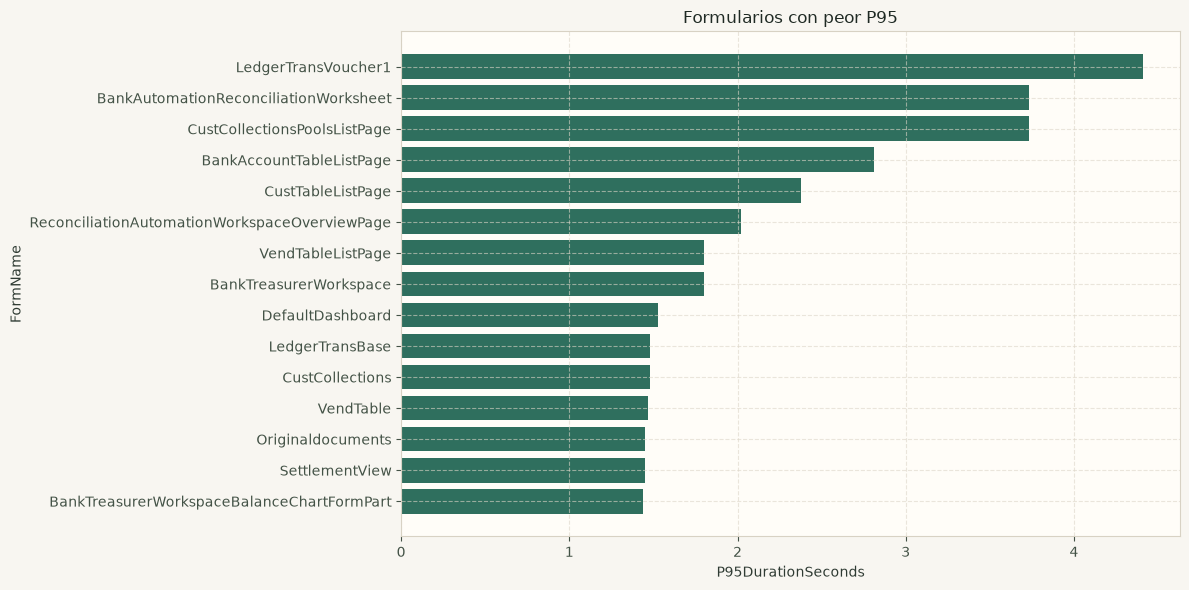

In [2]:
df_slow_forms = run_kql(client, load_kql('20_slow_forms.kql'), days=FORMS_DAYS, name='Slow forms', config=config)
display(df_slow_forms.head(TOP_N))
plot_bar(df_slow_forms, 'FormName', 'P95DurationSeconds', 'Formularios con peor P95', top_n=TOP_N)

Ejecutando: Most used forms
Filas devueltas: 30


,FormName,FormOpens
0,CustTrans,247
1,DimensionCombinationPreviewPart,205
2,DefaultDashboard,175
3,BankStatementGeneratePaymentDialog,150
4,BankAutomationReconciliationWorksheet,146
5,PWVendJournalIntegrationLog,124
6,LedgerTransAccountDisplayAllFiscalYear,119
7,CustTableListPage,119
8,LedgerTransVoucher1,115
9,CustOpenTrans,112


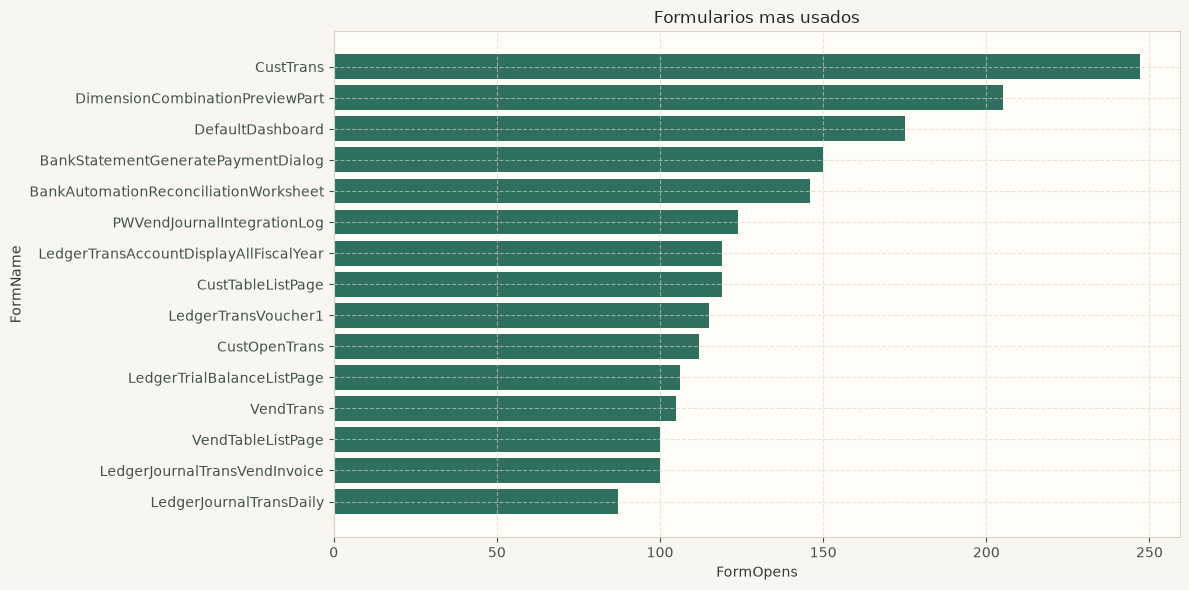

Ejecutando: Forms total impact
Filas devueltas: 30


,FormName,FormOpens,TotalDurationMinutes,AvgDurationSeconds,P95DurationSeconds
0,BatchJobEnhancedUser,2,1.065310e+09,3.195929e+10,6.391858e+10
1,BankAutomationReconciliationWorksheet,146,5.500000e+00,2.260000e+00,3.730000e+00
2,CustTableListPage,119,2.850000e+00,1.440000e+00,2.380000e+00
3,DefaultDashboard,175,2.300000e+00,7.900000e-01,1.530000e+00
4,CustTrans,247,2.150000e+00,5.200000e-01,1.330000e+00
5,VendTableListPage,100,2.130000e+00,1.280000e+00,1.800000e+00
6,LedgerJournalTransDaily,87,1.020000e+00,7.000000e-01,1.340000e+00
7,LedgerTransVoucher1,115,9.900000e-01,5.100000e-01,4.410000e+00
8,LedgerJournalTransVendInvoice,100,8.100000e-01,4.900000e-01,6.900000e-01
9,LedgerTransAccountDisplayAllFiscalYear,119,7.800000e-01,3.900000e-01,8.100000e-01


,FormName,TotalDurationMinutes
0,BatchJobEnhancedUser,1.065310e+09
1,BankAutomationReconciliationWorksheet,5.500000e+00
2,CustTableListPage,2.850000e+00
3,DefaultDashboard,2.300000e+00
4,CustTrans,2.150000e+00


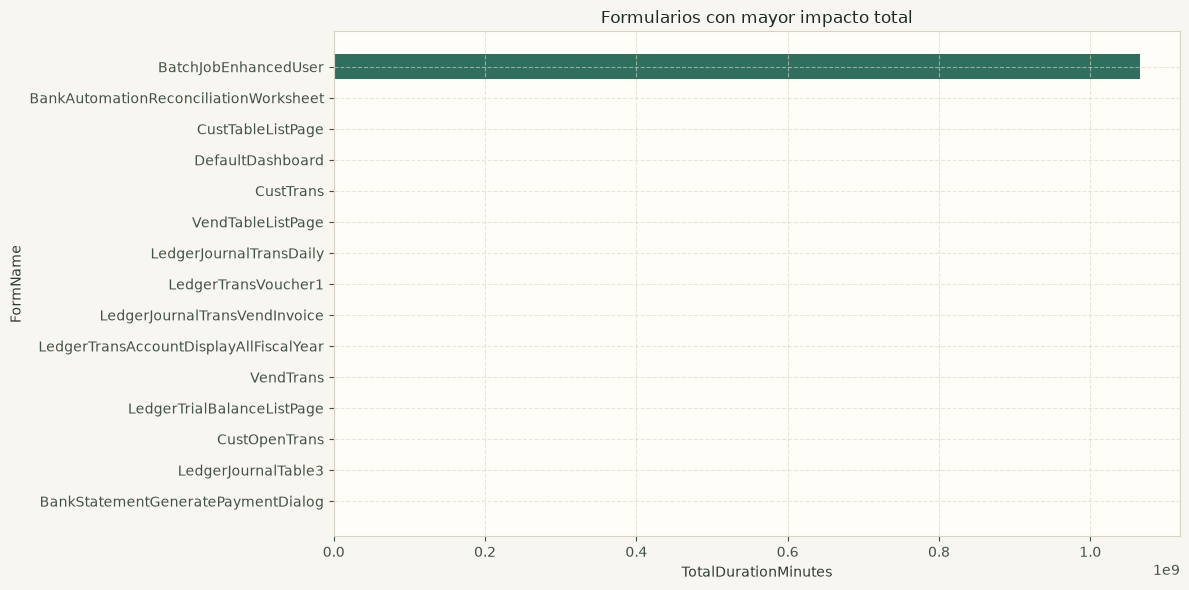

In [3]:
df_most_used = run_kql(client, load_kql('21_most_used_forms.kql'), days=FORMS_DAYS, name='Most used forms', config=config)
display(df_most_used.head(TOP_N))
plot_bar(df_most_used, 'FormName', 'FormOpens', 'Formularios mas usados', top_n=TOP_N)

df_total_impact = run_kql(client, load_kql('22_forms_total_impact.kql'), days=FORMS_DAYS, name='Forms total impact', config=config)
display(df_total_impact.head(TOP_N))
display(summarize_top_items(df_total_impact, 'FormName', 'TotalDurationMinutes', top_n=5))
plot_bar(df_total_impact, 'FormName', 'TotalDurationMinutes', 'Formularios con mayor impacto total', top_n=TOP_N)

## Criterios de priorizacion

- P95 alto indica dolor potencial; uso alto indica alcance; impacto total combina ambas cosas.
- Si un formulario es muy lento pero casi no se usa, puede ir a backlog y no al dashboard principal.
- Si buscas una sola visualizacion candidata, TotalDurationMinutes suele ser la mas accionable para negocio y operaciones.